# User Notebook

## Introduction

This user notebook provides an overview of the core commands of the STL library for statistical scattering analysis. Its purpose is to guide users through the fundamental operations required to compute **scattering statistics** and **cross-statistics between channels**, for both **periodic** and **non-periodic** domains. Other basic statistical quantities such as **mean**, **variance**, and **power spectrum** are also available.

Beyond analysis, the library also supports **data synthesis** based on target statistics. This notebook demonstrates how to define **custom loss functions** that compare statistical descriptors, and how to **run optimization procedures** to generate signals or fields that match desired statistical properties.

Examples are provided to illustrate typical workflows and recommended usage patterns.

Note:

- For **2D kernel** data: **mean**, **variance**, and **scattering coefficients** can be computed (periodic or non-periodic data, with or without NaN values).

- For **2D FFT** data: **mean**, **variance**, **scattering coefficients**, and **power spectrum** can be computed (periodic or non-periodic data — except for the power spectrum, which is currently computed only for PBC data; NaN values are non handled).

In [1]:
# Import useful libraries, test data path and STL modules

# Library imports
import numpy as np
import matplotlib.pyplot as plt
import torch

import os
import sys


# Add parent directory to sys.path to import STL package modules
PARENT_DIR = os.path.dirname(os.path.abspath(os.getcwd() + "../"))
sys.path.append(PARENT_DIR)
print("Parent directory added to sys.path:", ".../" + PARENT_DIR.split("//")[-1])

# Path to test data
DATA_TEST_PATH = PARENT_DIR + "/data" + "/test"
print("Dataset directory used:", ".../" + PARENT_DIR.split("/")[-1] + DATA_TEST_PATH.split(PARENT_DIR.split("/")[-1])[-1])

# STL package imports
from STL_main.STL_2D_Kernel_Torch import STL_2D_Kernel_Torch as DataClass
from STL_main.STL_2D_Kernel_Torch import WaveletOperator2Dkernel_torch as WaveletOp
from STL_main.Synthesis import optimize_scattering_LBFGS
from STL_main.torch_backend import _DEFAULT_DEVICE

print("Working on device:", _DEFAULT_DEVICE)

Parent directory added to sys.path: .../c:\Users\Danie\Bureau\STL-Dev
Dataset directory used: .../c:\Users\Danie\Bureau\STL-Dev/data/test
Working on device: cpu


In [2]:
# command to auto-reload modules when they are edited (easier for testing and debugging)
%load_ext autoreload
%autoreload 2

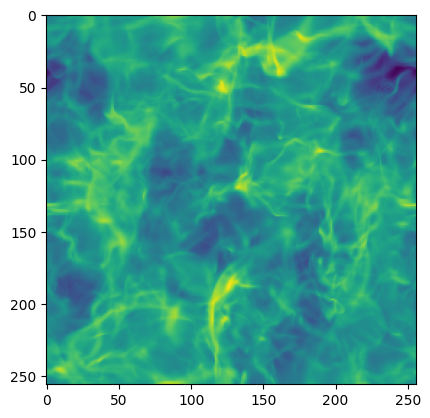

In [4]:
# Image loading
im = np.load(DATA_TEST_PATH + "/" + 'Turb_6.npy')[:,None,:,:]

# Instantiate STL data class
data = DataClass(array=im[0,0], pbc=True) # shall specify both array and pbc status

# Visualize loaded data
plt.imshow(data.array.cpu().numpy())



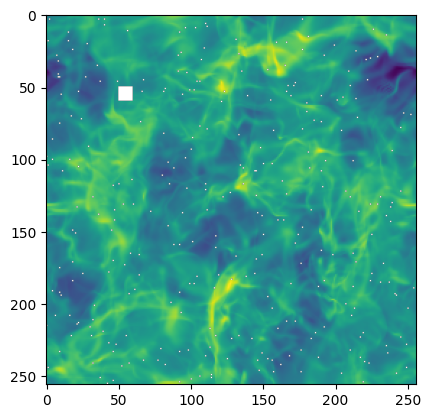

In [56]:
# ------------  NaN value handling ------------ #

# Generate data with NaN values
im_nan = im[0,0].copy()
np.random.seed(27)
im_nan[(np.random.rand(300)*im_nan.shape[0]).astype('int'),
    (np.random.rand(300)*im_nan.shape[0]).astype('int')] = np.nan
im_nan[50:60,50:60] = np.nan

# Instantiate STL data class with NaN values
data_nan = DataClass(im_nan, pbc=True)

# Visualize data with NaN values
plt.imshow(data_nan.array.cpu().numpy())
plt.show()

In [57]:
# get a ST operator from the data class
st_op = data.get_ST_op()
st_op_nan = data_nan.get_ST_op()

# apply the ST operator to the data
st_data = st_op.apply(data)
st_data_nan = st_op_nan.apply(data_nan)

Mean without NaN: 20.319511169164517
Mean with NaN: 20.319554960168997

Std without NaN: 412.94668070939105
Std with NaN: 412.9485534129324


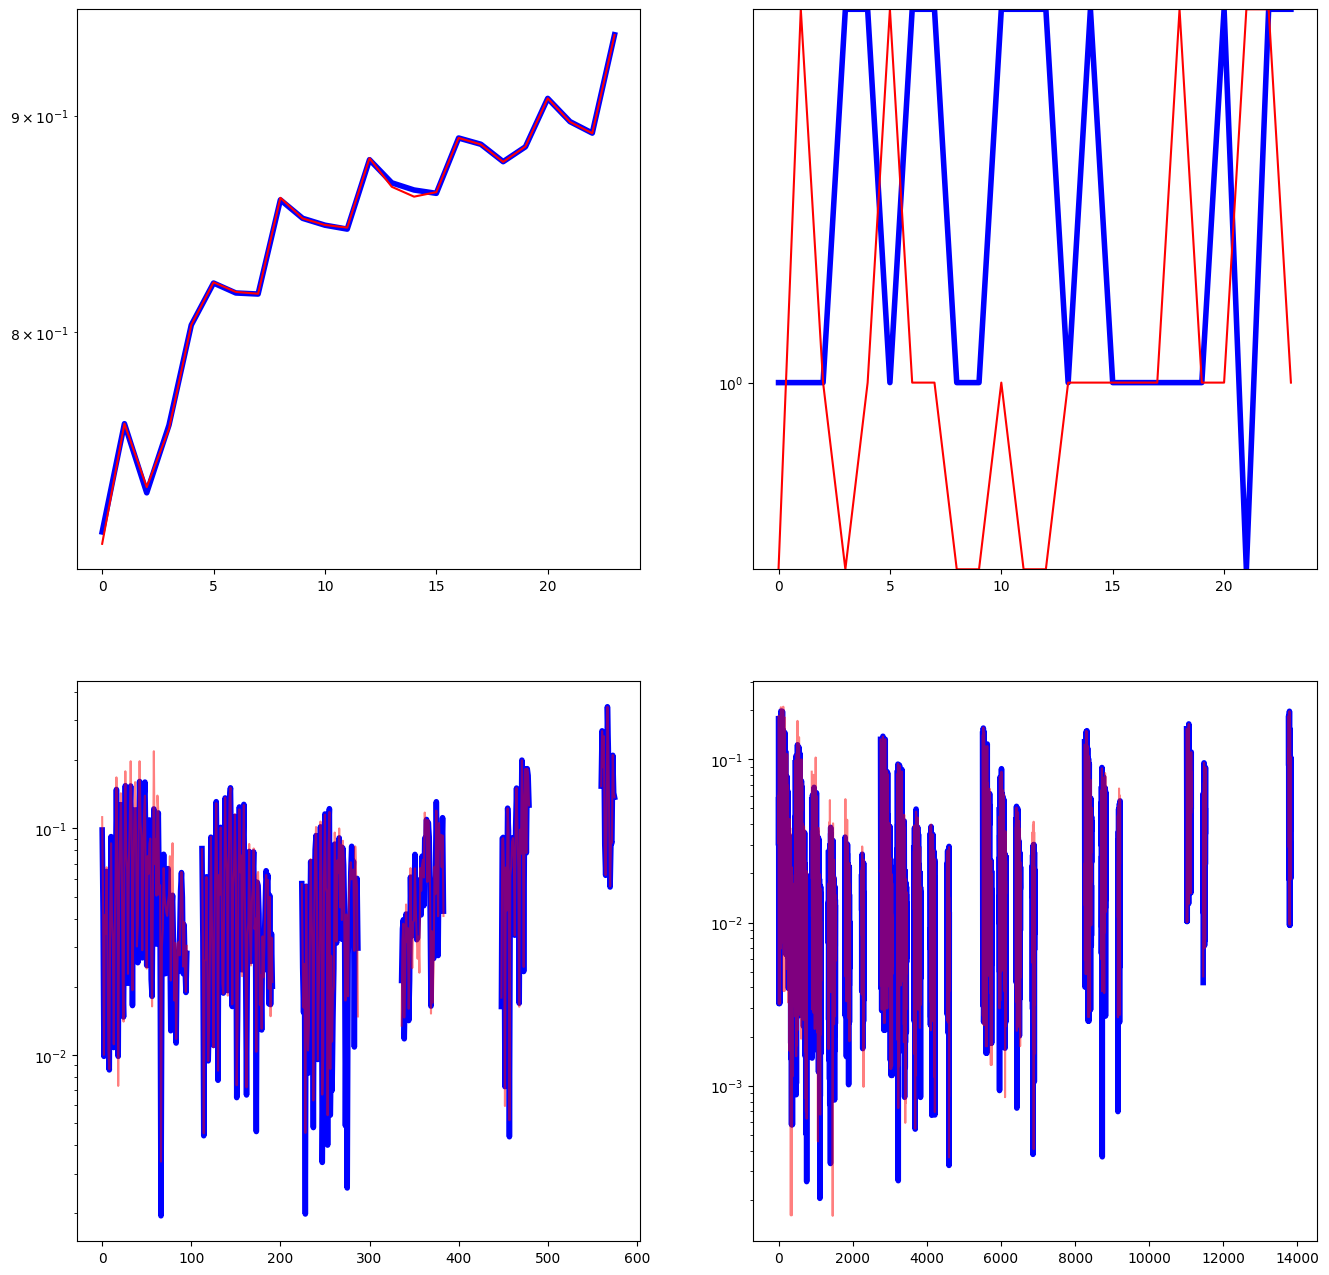

In [58]:
# Compare mean and std values
print("Mean without NaN:", st_data.mean.item())
print("Mean with NaN:", st_data_nan.mean.item())
print()
print("Std without NaN:", st_data.var.item())
print("Std with NaN:", st_data_nan.var.item())
plt.figure(figsize=(16,16))

# Plot and compare S1 coefficients (without and with NaN)
plt.subplot(2,2,1)
plt.plot(st_data.S1.cpu().numpy().flatten(),color='b',lw=4)
plt.plot(st_data_nan.S1.cpu().numpy().flatten(),color='r')
plt.yscale('log')

# Plot and compare S2 coefficients (without and with NaN)
plt.subplot(2,2,2)
plt.plot(st_data.S2.cpu().numpy().flatten(),color='b',lw=4)
plt.plot(st_data_nan.S2.cpu().numpy().flatten(),color='r')
plt.yscale('log')

# Plot and compare S3 coefficients (without and with NaN)
plt.subplot(2,2,3)
plt.plot(st_data.S3.abs().cpu().numpy().flatten(),color='b',lw=4)
plt.plot(st_data_nan.S3.abs().cpu().numpy().flatten(),color='r', alpha=0.5)
plt.yscale('log')

# Plot and compare S4 coefficients (without and with NaN)
plt.subplot(2,2,4)
plt.plot(st_data.S4.abs().cpu().numpy().flatten(),color='b',lw=4)
plt.plot(st_data_nan.S4.cpu().abs().numpy().flatten(),color='r', alpha=0.5)
plt.yscale('log')

### Scattering Coefficients Computation - (not PBC and without NaNs values)

There are several ways to handle non-PBC data.  
First, the data are convolved with wavelets, and cropping is applied when computing the mean or covariance.

- **Fully flexible:** the border size is computed to retain as many pixels as possible, based on the involved scale *j* and the convolution depth (i.e., the number of applied wavelets).
- **Largest-scale layer flexible:** the border size is computed conservatively with respect to the largest scale *J*, but it may be adapted to the convolution depth.
- **Largest-scale second layer:** the border size is computed in the most conservative way, using the largest scale *J* and a convolution depth of 2. In this case, all coefficients are estimated on the same set of pixels.


Warning! Data with shape (8, 8) too small to be cropped with border 4. Using border=3 instead.


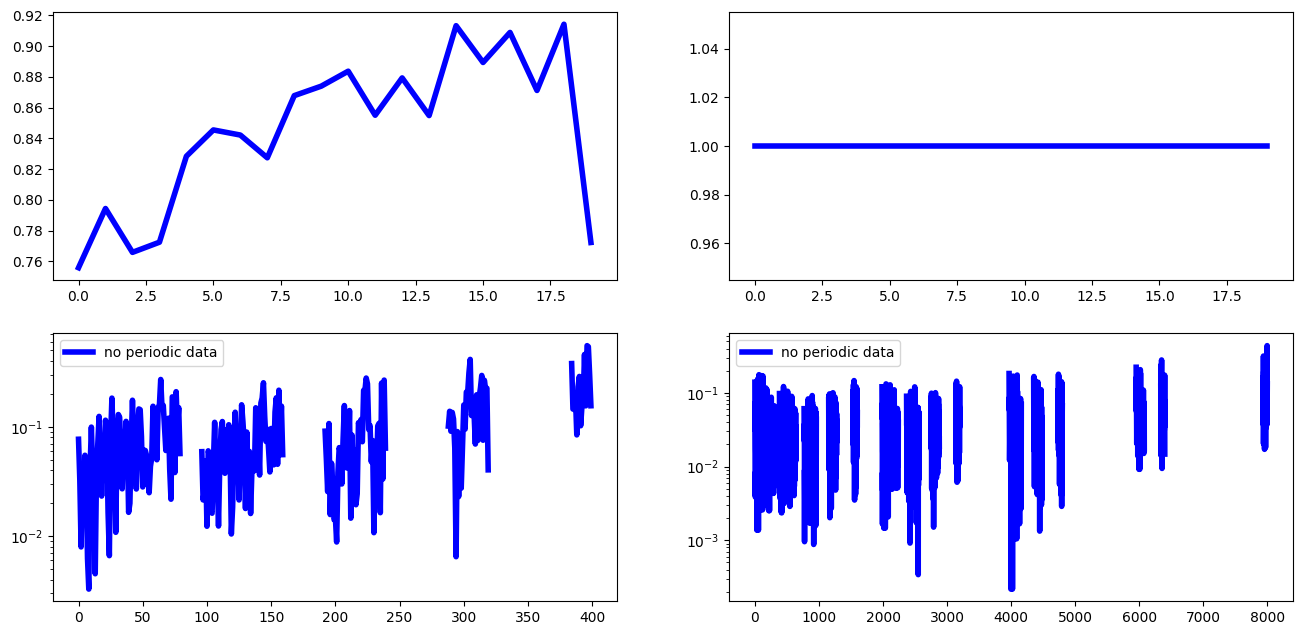

In [59]:
# ------------  No Periodic Boundary Conditions (No PBC) handlling ------------ # 

# Instantiate data class without PBC
data_npbc = DataClass(im[0,0,:128,:128], pbc=False) # crop pbc image to get no pbc image

st_op_npbc = data_npbc.get_ST_op(J=5)
st_data_npbc = st_op_npbc.apply(data_npbc)

plt.figure(figsize=(16,16))

plt.subplot(4,2,1)
plt.plot(st_data_npbc.S1.cpu().numpy().flatten(), color='blue', lw=4, label='no periodic data')

plt.subplot(4,2,2)
plt.plot(st_data_npbc.S2.cpu().numpy().flatten(), color='blue', lw=4, label='no periodic data')

plt.subplot(4,2,3)
plt.plot(st_data_npbc.S3.abs().cpu().numpy().flatten(), color='blue', lw=4, label='no periodic data')
plt.yscale('log')
plt.legend()

plt.subplot(4,2,4)
plt.plot(st_data_npbc.S4.cpu().abs().numpy().flatten(), color='blue', lw=4, label='no periodic data')
plt.yscale('log')
plt.legend()

### Mono Channel Synthesis

### Mean and Variance Checks 

In [ ]:
from STL_main.STL_2D_Kernel_Torch import STL_2D_Kernel_Torch

target = np.stack(im[0,0])
target = STL_2D_Kernel_Torch(target)

st_op = target.get_ST_op(has_fewer_convolutions=True)
# Parameters in get_stop for dimension reduction: iso = True,angular_ft = True, scale_ft = True, harmonics_scale=3, harmonics_angle=3,dj = 3

compute_cross_matrix = None

u1, histo1 = optimize_scattering_LBFGS(
        target=target,
        st_op_target=st_op,
        st_op_running=st_op,
        pbc_running=True,
        compute_cross_matrix=compute_cross_matrix,        
        nbatch=1,
        max_iter=50,
        lr=1.0,
        history_size=50,
        print_iter=10,
        verbose=True,
        seed=26,
    )

Running synthesis on device cpu dtype torch.float64
Initial shape for u: (1, 1, 256, 256)
Synthesis on 3970 ST coefficients
[LBFGS] inner iter 10, loss = 1.886398e+02
[LBFGS] inner iter 20, loss = 9.423338e+00
[LBFGS] inner iter 30, loss = 5.920833e-01
[LBFGS] inner iter 40, loss = 2.092290e-01
[LBFGS] inner iter 50, loss = 1.384671e-01
58 iterations of synthesis done with nbatch=1 and 3970 ST coefficients
Execution time: 42.155 s


In [6]:
print(target.array.mean(), target.array.std())
print(u1.mean(), u1.std())

tensor(20.3195, dtype=torch.float64) tensor(0.2533, dtype=torch.float64)
tensor(20.3193, dtype=torch.float64) tensor(0.2460, dtype=torch.float64)


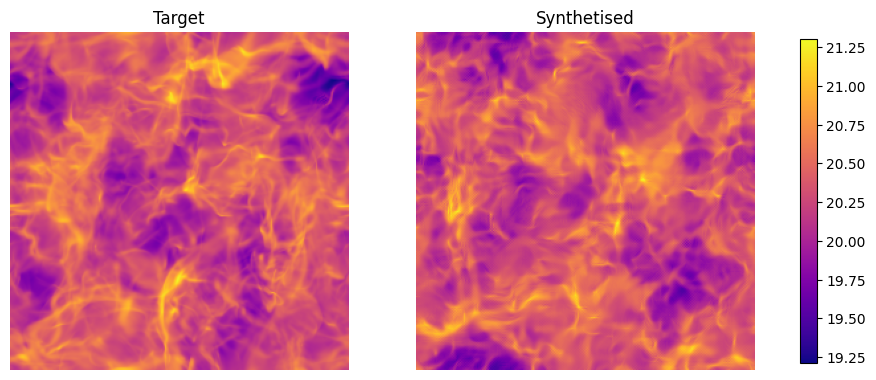

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

t = target.array.cpu().numpy()
u = u1.cpu().numpy()

vmin = min(t.min(), u.min())
vmax = max(t.max(), u.max())

im0 = axes[0].imshow(t, cmap="plasma", vmin=vmin, vmax=vmax)
axes[0].axis("off")
axes[0].set_title("Target")

im1 = axes[1].imshow(u, cmap="plasma", vmin=vmin, vmax=vmax)
axes[1].axis("off")
axes[1].set_title("Synthetised")

fig.colorbar(im0, ax=axes, shrink=0.7)
plt.show()

In [ ]:
from STL_main.STL_2D_FFT_Torch import STL_2D_FFT_Torch

target = np.stack(im[0,0])
target = STL_2D_FFT_Torch(target, pbc=True)

st_op = target.get_ST_op(has_fewer_convolutions=True)

compute_cross_matrix = None

u1, histo1 = optimize_scattering_LBFGS(
        target=target,
        st_op_target=st_op,
        st_op_running=st_op,
        pbc_running=True,
        compute_cross_matrix=compute_cross_matrix,        
        nbatch=1,
        max_iter=50,
        lr=1.0,
        history_size=50,
        print_iter=10,
        verbose=True,
        seed=26,
    )

Running synthesis on device cpu dtype torch.float64
Initial shape for u: (1, 1, 256, 256)
Synthesis on 3970 ST coefficients
[LBFGS] inner iter 10, loss = 4.295230e+02
[LBFGS] inner iter 20, loss = 8.697826e+00
[LBFGS] inner iter 30, loss = 3.936035e-01
[LBFGS] inner iter 40, loss = 2.049769e-01
[LBFGS] inner iter 50, loss = 1.407750e-01
58 iterations of synthesis done with nbatch=1 and 3970 ST coefficients
Execution time: 25.796 s


In [10]:
print(target.array.mean(), target.array.std())
print(u1.mean(), u1.std())

tensor(20.3195, dtype=torch.float64) tensor(0.2533, dtype=torch.float64)
tensor(20.3201, dtype=torch.float64) tensor(0.2374, dtype=torch.float64)


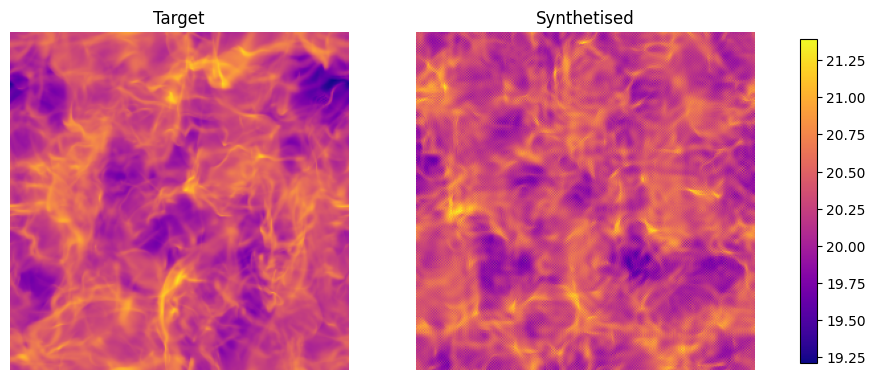

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

t = target.array.cpu().numpy()
u = u1.cpu().numpy()

vmin = min(t.min(), u.min())
vmax = max(t.max(), u.max())

im0 = axes[0].imshow(t, cmap="plasma", vmin=vmin, vmax=vmax)
axes[0].axis("off")
axes[0].set_title("Target")

im1 = axes[1].imshow(u, cmap="plasma", vmin=vmin, vmax=vmax)
axes[1].axis("off")
axes[1].set_title("Synthetised")

fig.colorbar(im0, ax=axes, shrink=0.7)
plt.show()

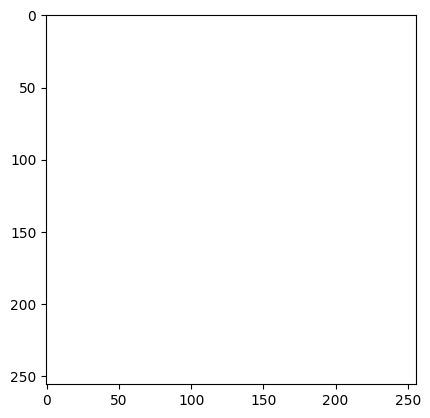

In [71]:
plt.imshow(torch.fft.fftshift(u1).cpu().numpy(), cmap="plasma")

### Mono Channel Synthesis with NaNs

In [72]:
im = np.reshape(np.load(DATA_TEST_PATH + "/" + "patch_129_main.npy"), (2,1,384,384))
data = DataClass(array=im[0,0], pbc=False)
st_op = data.get_ST_op()

im_nan = np.where(im > 0.05, np.nan, im)
target = np.stack(im_nan[0,0])
target = DataClass(target, pbc=False)
st_op_nan = target.get_ST_op()


u1, histo1 = optimize_scattering_LBFGS(
        target=target,
        st_op_target=st_op_nan,
        st_op_running=st_op,
        pbc_running=False,
        compute_cross_matrix=None,        
        nbatch=1,
        max_iter=20,
        lr=1.0,
        history_size=50,
        print_iter=10,
        verbose=True,
        seed=26,
    )

Running synthesis on device cpu dtype torch.float64
NaN detected in the target, the synthesis takes it into account
Initial shape for u: (1, 1, 384, 384)
Synthesis on 3970 ST coefficients
[LBFGS] inner iter 10, loss = 1.625739e+02
[LBFGS] inner iter 20, loss = 1.721879e+01
25 iterations of synthesis done with nbatch=1 and 3970 ST coefficients
Execution time: 50.220 s


### Multi Channels Synthesis

In [74]:
target = np.stack([im[0,0], (im[0,0]-im[0,0].mean(keepdims=True))**2])
target -= target.mean(axis=(1,2), keepdims=True)
target = DataClass(target, pbc=True)

st_op = target.get_ST_op()

compute_cross_matrix = torch.tensor([[1, 1], [0, 1]], dtype=torch.bool)
compute_cross_matrix

u1, histo1 = optimize_scattering_LBFGS(
        target=target,
        st_op_target=st_op,
        st_op_running=st_op,
        pbc_running=True,
        compute_cross_matrix=compute_cross_matrix,        
        nbatch=4,
        max_iter=50,
        lr=1.0,
        history_size=50,
        print_iter=10,
        verbose=True,
        seed=26,
    )

(2, 384, 384)
Running synthesis on device cpu dtype torch.float64
Initial shape for u: (4, 2, 384, 384)


c:\Users\Danie\Bureau\STL-Dev\STL_main\STL_2D_Kernel_Torch.py:801: UserWarning: Casting complex values to real discards the imaginary part (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\Copy.cpp:308.)
  output[:, c1, c2, ...] = self.cov(


Synthesis on 15804 ST coefficients


KeyboardInterrupt: 

In [21]:
def plot_scattering_coeffs(
    st_data1,
    st_data2,
    suptitle,
    label_st_data1,
    label_st_data2
):
    plt.figure(figsize=(10, 8))

    # --- S1 ---
    plt.subplot(2,2,1)
    plt.plot(st_data1.S1.cpu().numpy().flatten(), color='b', label=label_st_data1)
    plt.plot(st_data2.S1.cpu().numpy().flatten(), color='r', label=label_st_data2, linewidth=0.7)
    plt.yscale('log')
    plt.title('S1')
    plt.legend()

    # --- S2 ---
    plt.subplot(2,2,2)
    plt.plot(st_data1.S2.cpu().numpy().flatten(), color='b', label=label_st_data1)
    plt.plot(st_data2.S2.cpu().numpy().flatten(), color='r', label=label_st_data2, linewidth=0.7)
    plt.yscale('log')
    plt.title('S2')
    plt.legend()

    # --- S3 ---
    plt.subplot(2,2,3)
    plt.plot(st_data1.S3.abs().cpu().numpy().flatten(), color='b', label=label_st_data1)
    plt.plot(st_data2.S3.abs().cpu().numpy().flatten(), color='r', label=label_st_data2, linewidth=0.7)
    plt.yscale('log')
    plt.title('S3')
    plt.legend()

    # --- S4 ---
    plt.subplot(2,2,4)
    plt.plot(st_data1.S4.abs().cpu().numpy().flatten(), color='b', label=label_st_data1)
    plt.plot(st_data2.S4.abs().cpu().numpy().flatten(), color='r', label=label_st_data2, linewidth=0.7)
    plt.yscale('log')
    plt.title('S4')
    plt.legend()

    plt.suptitle(suptitle, fontsize=16)

    plt.tight_layout(rect=[0, 0, 1, 0.95]) 
    plt.show()  


In [ ]:
# Image loading
im = np.load(DATA_TEST_PATH + "/" + 'Turb_6.npy')[:,None,:,:]

## Scattering Coefficients Computation

| PBC | Mask (NaNs) | Channel(s) | Comparison Statistics |
|-----|-------------|---------|-----------------------|
| PBC image | No mask | Mono + Cross | Kernel vs FFT |
| non-PBC image | No mask | Mono | (PBC vs non-PBC) - Kernel + FFT|
| PBC image | Mask | Mono | (mask vs no mask) - Kernel |


#### PBC - No Mask

In [ ]:
from STL_main.STL_2D_Kernel_Torch import 
from STL_main.STL_2D_FFT_Torch import STL_2D_FFT_Torch as FFT_DataClass

In [83]:
white_noise = np.random.randn(*im[0,0].shape)

In [84]:
# Instantiate STL data classes
data_kernel = Kernel_DataClass(array=white_noise, pbc=True)
data_fft = FFT_DataClass(array=white_noise, pbc=True)

# Get a ST operator from the data classes
st_op_kernel = data_kernel.get_ST_op()
st_op_fft = data_fft.get_ST_op()

# apply the ST operator to the data
st_data_kernel = st_op_kernel.apply(data_kernel)
st_data_fft = st_op_fft.apply(data_fft)

NameError: name 'Kernel_DataClass' is not defined

In [22]:
plot_scattering_coeffs(
    st_data_kernel,
    st_data_fft,
    suptitle='Scattering Coefficients (Kernel vs FFT)',
    label_st_data1='Kernel',
    label_st_data2='FFT'
)

NameError: name 'st_data_kernel' is not defined

### Not PBC - No Mask

#### Kernel

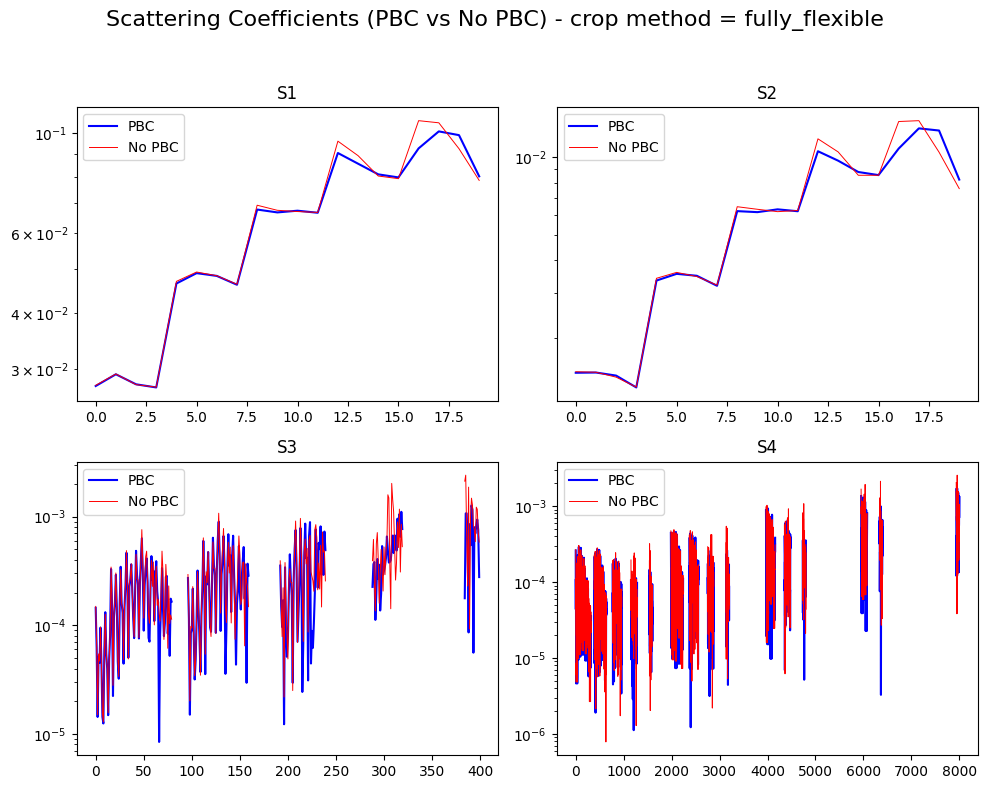

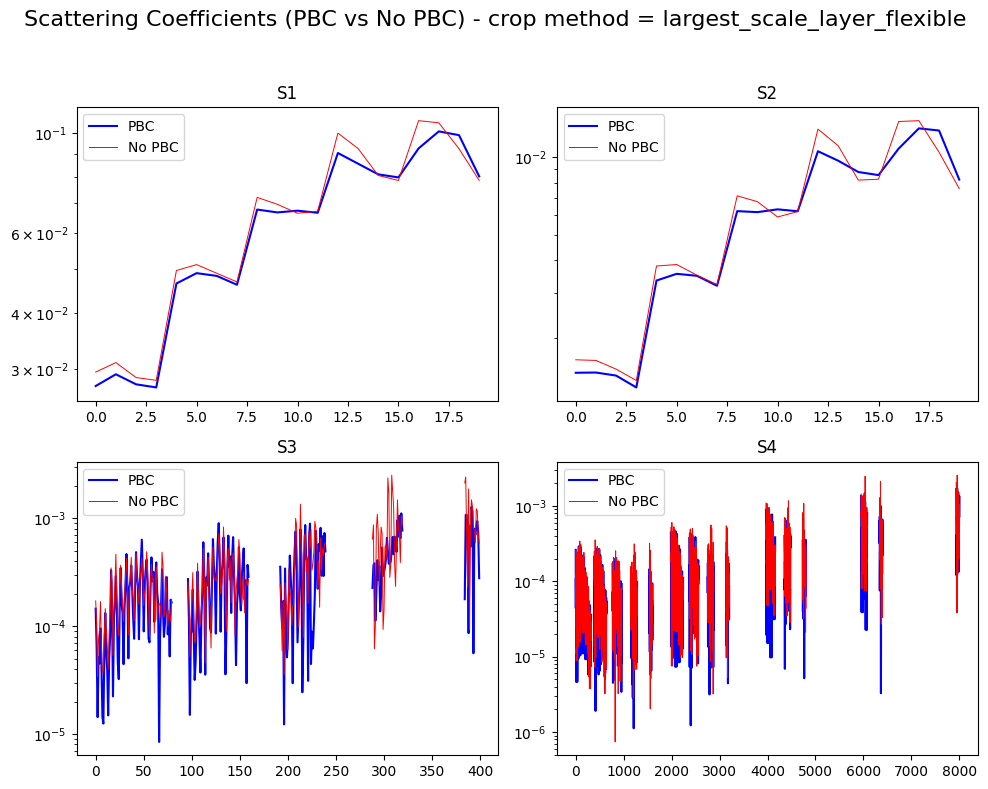

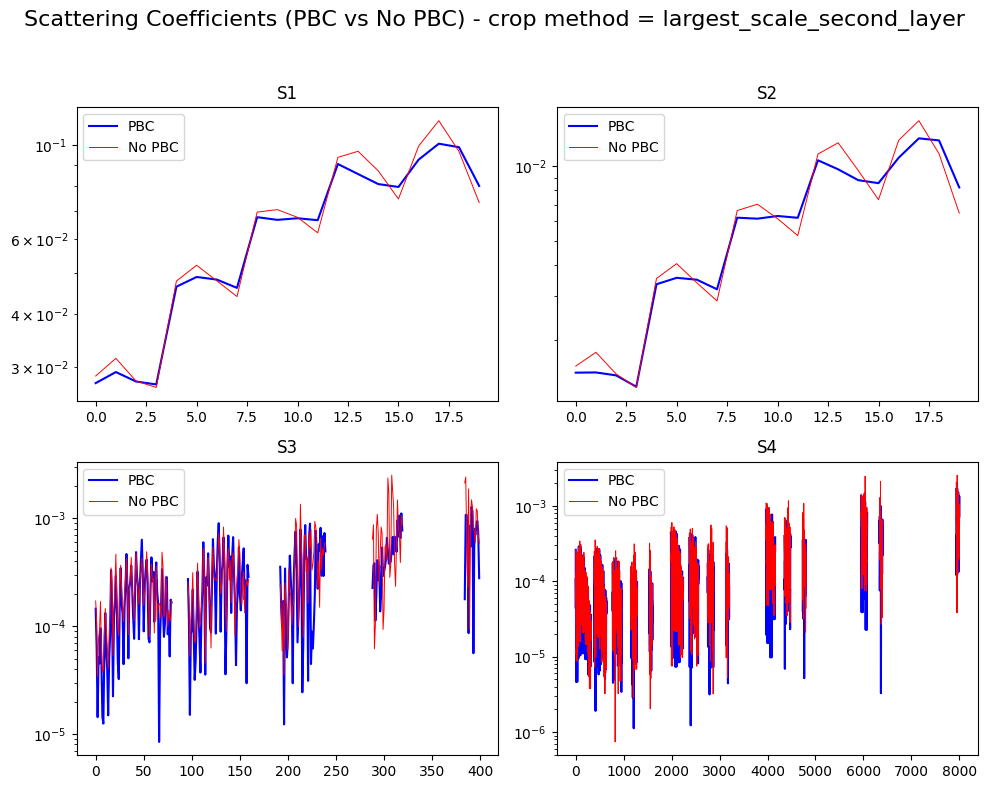

In [40]:
from STL_main.STL_2D_Kernel_Torch import STL_2D_Kernel_Torch, WaveletOperator2Dkernel_torch

# Instantiate kernel data class (pbc and no pbc)
data_kernel_pbc = STL_2D_Kernel_Torch(array=im[0,0], pbc=True)
data_kernel_no_pbc = STL_2D_Kernel_Torch(array=im[0,0], pbc=False)

# Liste des méthodes à tester
methods = [
    ("fully_flexible", WaveletOperator2Dkernel_torch._get_crop_border_size_fully_flexible),
    ("largest_scale_layer_flexible", WaveletOperator2Dkernel_torch._get_crop_border_size_largest_scale_layer_flexible),
    ("largest_scale_second_layer", WaveletOperator2Dkernel_torch._get_crop_border_size_largest_scale_second_layer),
]

for name, method in methods:

    # Get ST operator
    st_op_kernel = data_kernel_pbc.get_ST_op(J = 5, get_crop_border_size_method=method)

    # Apply
    st_data_kernel_pbc = st_op_kernel.apply(data_kernel_pbc, norm='vanilla')
    st_data_kernel_no_pbc = st_op_kernel.apply(data_kernel_no_pbc, norm='vanilla')

    # Plot
    plot_scattering_coeffs(
        st_data_kernel_pbc,
        st_data_kernel_no_pbc,
        suptitle=f'Scattering Coefficients (PBC vs No PBC) - crop method = {name}',
        label_st_data1='PBC',
        label_st_data2='No PBC'
    )

#### FFT 

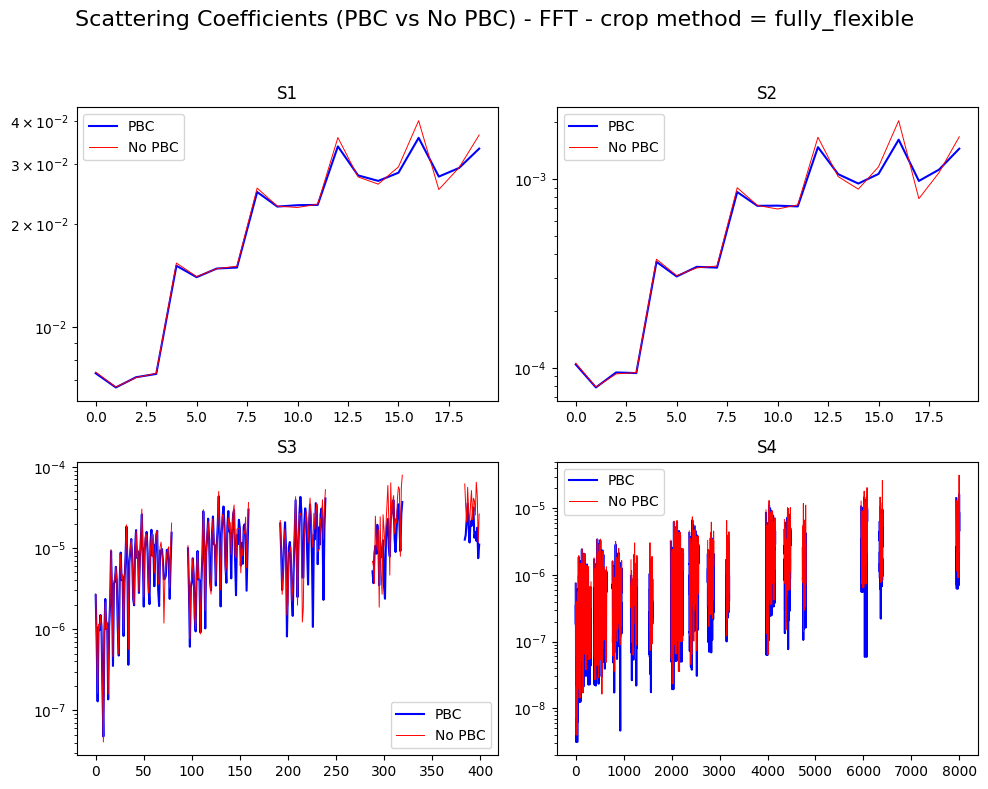

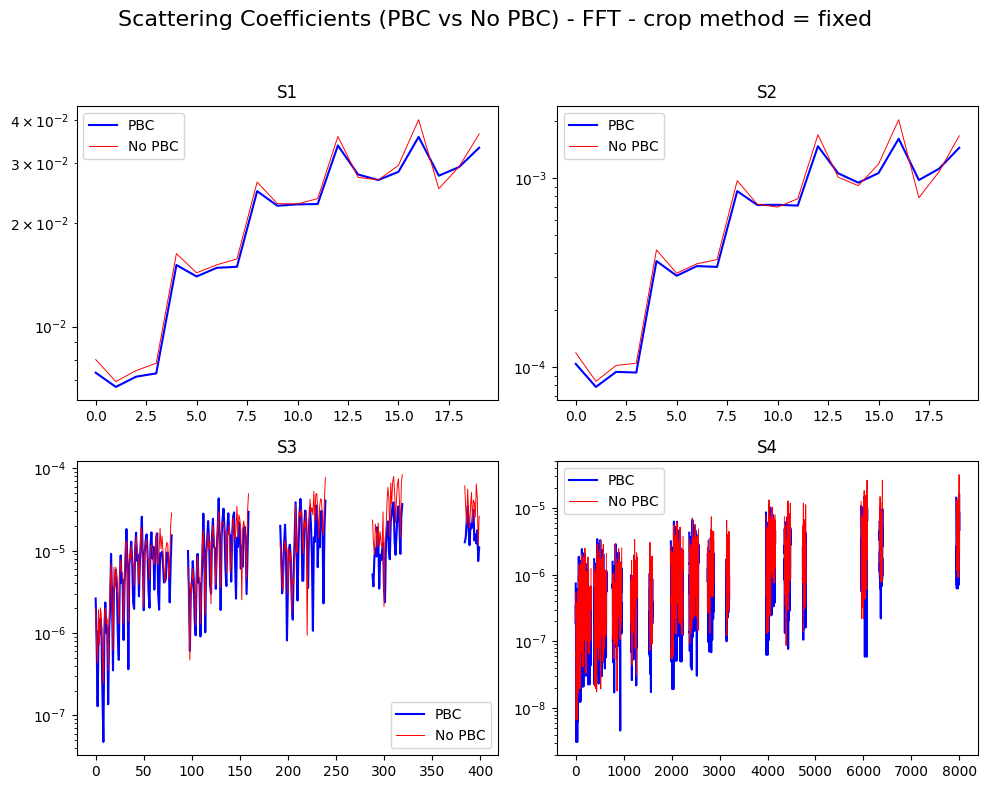

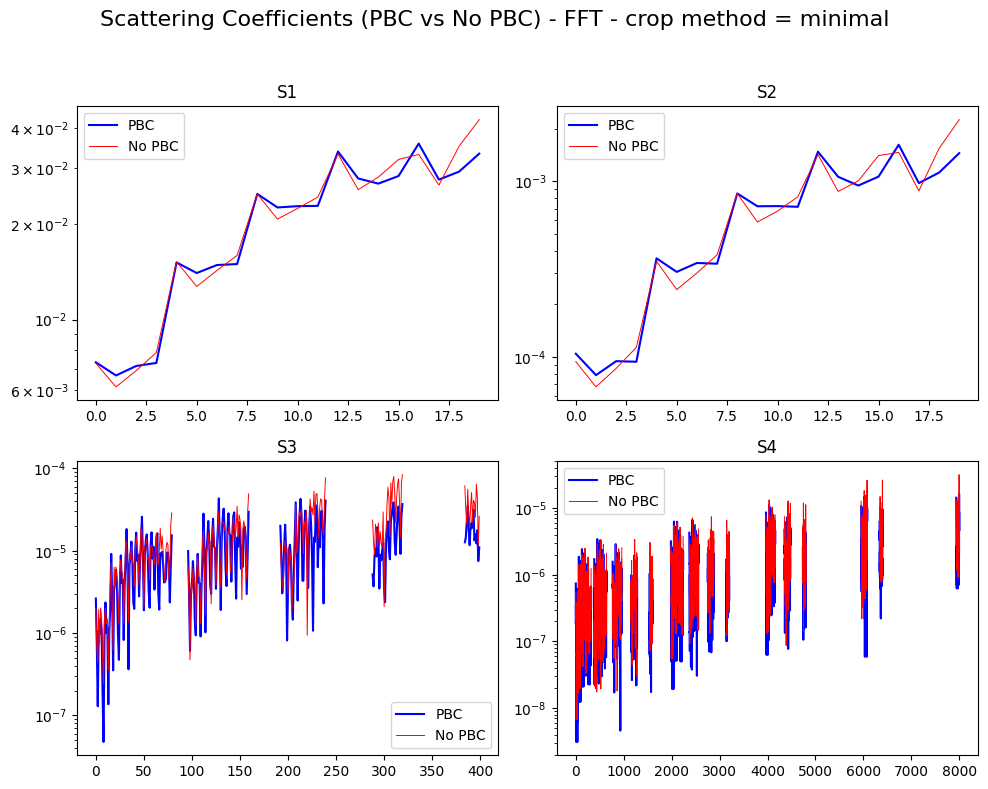

In [ ]:
from STL_main.STL_2D_FFT_Torch import STL_2D_FFT_Torch, WaveletOperator2D_FFT_torch

# Instantiate kernel data class (pbc and no pbc)
data_fft_pbc = STL_2D_FFT_Torch(array=im[0,0], pbc=True)
data_fft_no_pbc = STL_2D_FFT_Torch(array=im[0,0], pbc=False)

# Liste des méthodes à tester
methods = [
    ("fully_flexible", WaveletOperator2D_FFT_torch._get_crop_border_size_fully_flexible),
    ("largest_scale_layer_flexible", WaveletOperator2D_FFT_torch._get_crop_border_size_largest_scale_layer_flexible),
    ("largest_scale_second_layer", WaveletOperator2D_FFT_torch._get_crop_border_size_largest_scale_second_layer),
]

for name, method in methods:

    # Get ST operator
    st_op_fft = data_fft_pbc.get_ST_op(J = 5, WType = "Bump-Steerable", get_crop_border_size_method=method)

    # Apply
    st_data_fft_pbc = st_op_fft.apply(data_fft_pbc, norm='vanilla')
    st_data_fft_no_pbc = st_op_fft.apply(data_fft_no_pbc, norm='vanilla')

    # Plot
    plot_scattering_coeffs(
        st_data_fft_pbc,
        st_data_fft_no_pbc,
        suptitle=f'Scattering Coefficients (PBC vs No PBC) - FFT - crop method = {name}',
        label_st_data1='PBC',
        label_st_data2='No PBC'
    )

#### PBC - Mask

## Synthesis

| Category | Input image(s) | Output image(s) | Channel(s) | Method(s) |
|----------|---------------|-----------------|---------|--------|
| One → One | 1 PBC image | 1 PBC image | Mono + Cross | Kernel + FFT |
| Many → One | N PBC images | 1 PBC image | Mono | Kernel + FFT |
| One → Many | 1 PBC image | N PBC images | Mono | Kernel + FFT |
| Many → Many | N PBC images | M PBC images | Mono | Kernel + FFT |
| PBC → Non PBC | 1 PBC image | 1 non-PBC image | Mono | Kernel + FFT |
| Non PBC → PBC | 1 non-PBC image | 1 PBC image | Mono | Kernel + FFT |
| Non PBC → Non PBC | 1 non-PBC image | 1 non-PBC image | Mono | Kernel + FFT |
| NaNs → NaNs | 1 image with NaNs | 1 image with NaNs | Mono | Kernel |
| NaNs → NaNs (≠ Mask)| 1 image with NaNs  | 1 image with NaNs | Mono | Kernel |
| Non NaNs → NaNs | 1 image without NaNs | 1 image with NaNs | Mono | Kernel |
| NaNs → Non NaNs | 1 image with NaNs | 1 image without NaNs | Mono | Kernel |


#### One → One 

#### Many → One

#### One → Many

#### Many → Many

#### PBC → Non PBC

#### Non PBC → PBC

#### Non PBC → Non PBC

#### NaNs → NaNs

#### NaNs → NaNs (≠ Mask)

#### Non NaNs → NaNs

#### NaNs → Non NaNs